# **Import Library**

In [101]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.layers import Bidirectional, Dense, LSTM, Embedding, SpatialDropout1D, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import pickle
import re
import seaborn as sns
import string
nltk.download('punkt') 
nltk.download('stopwords') 
np.random.seed(0)
pd.options.mode.chained_assignment = None

[nltk_data] Downloading package punkt to /home/bima/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/bima/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **Loading Dataset**

In [ ]:
# Membaca dataset ulasan aplikasi Minecraft
app_reviews_df = pd.read_csv('Dataset/Minecraft_Review.csv')
app_reviews_df = app_reviews_df[['content']]

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

print("Jumlah baris:", jumlah_ulasan)
print("Jumlah kolom:", jumlah_kolom)

Jumlah baris: 63000
Jumlah kolom: 1


In [15]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,content
0,I really like the game but my account lost all...
1,As someone who has played Minecraft since a ye...
2,"Used to have a 5 star review, but I've decided..."
3,"I've been playing Minecraft since late 2014, a..."
4,"As this is Minecraft after all, it's pretty se..."


In [16]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63000 entries, 0 to 62999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  63000 non-null  object
dtypes: object(1)
memory usage: 492.3+ KB


In [17]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [18]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan nilai yang hilang (NaN)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63000 entries, 0 to 62999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  63000 non-null  object
dtypes: object(1)
memory usage: 492.3+ KB


In [19]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

print("Jumlah baris sebelum menghapus duplikat:", jumlah_ulasan)
print("Jumlah baris setelah menghapus duplikat:", jumlah_ulasan_setelah_hapus_duplikat)

Jumlah baris sebelum menghapus duplikat: 63000
Jumlah baris setelah menghapus duplikat: 62916


## Preprocessing

In [20]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers
    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwors in a text
    listStopwords = set(stopwords.words('english'))
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Membuat objek stemmer
    stemmer = PorterStemmer()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in text]

    return stemmed_words

def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [ ]:
%%time

# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_casefoldingText'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Stemming teks dan menyimpannya di 'text_stemmingText'
clean_df['text_stemmingText'] = clean_df['text_stopword'].apply(stemmingText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stemmingText'].apply(toSentence)

CPU times: user 32.5 s, sys: 750 ms, total: 33.3 s
Wall time: 33.4 s


In [22]:
clean_df.head(5)

,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_stemmingText,text_akhir
0,I really like the game but my account lost all...,I really like the game but my account lost all...,i really like the game but my account lost all...,"[i, really, like, the, game, but, my, account,...","[really, like, game, account, lost, mine, coin...","[realli, like, game, account, lost, mine, coin...",realli like game account lost mine coin editor...
1,As someone who has played Minecraft since a ye...,As someone who has played Minecraft since a ye...,as someone who has played minecraft since a ye...,"[as, someone, who, has, played, minecraft, sin...","[someone, played, minecraft, since, year, rele...","[someon, play, minecraft, sinc, year, releas, ...",someon play minecraft sinc year releas even po...
2,"Used to have a 5 star review, but I've decided...",Used to have a star review but Ive decided to...,used to have a star review but ive decided to...,"[used, to, have, a, star, review, but, ive, de...","[used, star, review, ive, decided, move, mobil...","[use, star, review, ive, decid, move, mobil, v...",use star review ive decid move mobil version b...
3,"I've been playing Minecraft since late 2014, a...",Ive been playing Minecraft since late and I L...,ive been playing minecraft since late and i l...,"[ive, been, playing, minecraft, since, late, a...","[ive, playing, minecraft, since, late, lovee, ...","[ive, play, minecraft, sinc, late, love, itt, ...",ive play minecraft sinc late love itt heart ev...
4,"As this is Minecraft after all, it's pretty se...",As this is Minecraft after all its pretty self...,as this is minecraft after all its pretty self...,"[as, this, is, minecraft, after, all, its, pre...","[minecraft, pretty, self, explanatory, theres,...","[minecraft, pretti, self, explanatori, there, ...",minecraft pretti self explanatori there noth n...


## **Labelling (TextBlob)**

In [ ]:
%%time

clean_df['polarity'] = clean_df['text_akhir'].apply(lambda x: TextBlob(x).sentiment.polarity)
clean_df.head(2)

CPU times: user 12.2 s, sys: 8.39 ms, total: 12.2 s
Wall time: 12.5 s


,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_stemmingText,text_akhir,polarity
0,I really like the game but my account lost all...,I really like the game but my account lost all...,i really like the game but my account lost all...,"[i, really, like, the, game, but, my, account,...","[really, like, game, account, lost, mine, coin...","[realli, like, game, account, lost, mine, coin...",realli like game account lost mine coin editor...,0.23125
1,As someone who has played Minecraft since a ye...,As someone who has played Minecraft since a ye...,as someone who has played minecraft since a ye...,"[as, someone, who, has, played, minecraft, sin...","[someone, played, minecraft, since, year, rele...","[someon, play, minecraft, sinc, year, releas, ...",someon play minecraft sinc year releas even po...,0.25000


In [24]:
def polarity_to_label(x):
    if(x >= -1 and x < 0):
        return 'neg'
    if(x == 0):
        return 'neutral'
    if(x > 0 and x <= 1):
        return 'pos'

clean_df['label'] = clean_df['polarity'].apply(polarity_to_label)
clean_df.head(2)

,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_stemmingText,text_akhir,polarity,label
0,I really like the game but my account lost all...,I really like the game but my account lost all...,i really like the game but my account lost all...,"[i, really, like, the, game, but, my, account,...","[really, like, game, account, lost, mine, coin...","[realli, like, game, account, lost, mine, coin...",realli like game account lost mine coin editor...,0.23125,pos
1,As someone who has played Minecraft since a ye...,As someone who has played Minecraft since a ye...,as someone who has played minecraft since a ye...,"[as, someone, who, has, played, minecraft, sin...","[someone, played, minecraft, since, year, rele...","[someon, play, minecraft, sinc, year, releas, ...",someon play minecraft sinc year releas even po...,0.25000,pos


In [25]:
clean_df['label'].value_counts()

label
pos        36644
neg        20789
neutral     5483
Name: count, dtype: int64

## **Imbalance Data Handling (Undersampling)**

In [26]:
clean_df.value_counts('label')

label
pos        36644
neg        20789
neutral     5483
Name: count, dtype: int64

In [27]:
# Mendapatkan nilai terkecil dari jumlah label
label_counts = clean_df['label'].value_counts()
min_label_count = label_counts.min()
print(f"Jumlah label terkecil: {min_label_count}")

# Pisahkan DataFrame berdasarkan kategori label
positive_df = clean_df[clean_df['label'] == 'pos'].iloc[:min_label_count]
neutral_df = clean_df[clean_df['label'] == 'neutral'].iloc[:min_label_count]
negative_df = clean_df[clean_df['label'] == 'neg'].iloc[:min_label_count]

print(positive_df.shape)
print(neutral_df.shape)
print(negative_df.shape)

Jumlah label terkecil: 5483
(5483, 9)
(5483, 9)
(5483, 9)


In [28]:
# Gabungkan kembali DataFrame
balanced_df = pd.concat([positive_df, neutral_df, negative_df])

# Reset index DataFrame
balanced_df = balanced_df.reset_index(drop=True)

# Display the balanced DataFrame
balanced_df.head()

,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_stemmingText,text_akhir,polarity,label
0,I really like the game but my account lost all...,I really like the game but my account lost all...,i really like the game but my account lost all...,"[i, really, like, the, game, but, my, account,...","[really, like, game, account, lost, mine, coin...","[realli, like, game, account, lost, mine, coin...",realli like game account lost mine coin editor...,0.231250,pos
1,As someone who has played Minecraft since a ye...,As someone who has played Minecraft since a ye...,as someone who has played minecraft since a ye...,"[as, someone, who, has, played, minecraft, sin...","[someone, played, minecraft, since, year, rele...","[someon, play, minecraft, sinc, year, releas, ...",someon play minecraft sinc year releas even po...,0.250000,pos
2,Minecraft is a fun game to play with friends (...,Minecraft is a fun game to play with friends I...,minecraft is a fun game to play with friends i...,"[minecraft, is, a, fun, game, to, play, with, ...","[minecraft, fun, game, play, friends, guess, t...","[minecraft, fun, game, play, friend, guess, th...",minecraft fun game play friend guess that moja...,0.012121,pos
3,"I bought some Minecoins through the app, and I...",I bought some Minecoins through the app and Iv...,i bought some minecoins through the app and iv...,"[i, bought, some, minecoins, through, the, app...","[bought, minecoins, app, ive, purchase, progre...","[bought, minecoin, app, ive, purchas, progress...",bought minecoin app ive purchas progress take ...,0.200000,pos
4,"I would rate the game five stars. It's fun, do...",I would rate the game five stars Its fun doesn...,i would rate the game five stars its fun doesn...,"[i, would, rate, the, game, five, stars, its, ...","[would, rate, game, five, stars, fun, doesnt, ...","[would, rate, game, five, star, fun, doesnt, t...",would rate game five star fun doesnt take much...,0.116667,pos


## **Visualization**

### Class Distribution Pie Chart

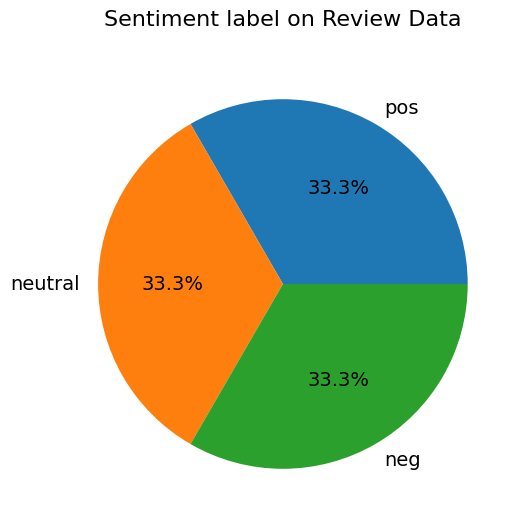

In [19]:
# Membuat objek gambar dan sumbu dengan ukuran (6, 6) inci.
fig, ax = plt.subplots(figsize=(6, 6))

# Mengambil jumlah data polaritas sentimen dari DataFrame 'balanced_df' dan menyimpannya dalam list 'sizes'.
sizes = [count for count in balanced_df['label'].value_counts()]

# Mengambil label atau kategori sentimen dari DataFrame 'balanced_df' dan menyimpannya dalam list 'labels'.
labels = list(balanced_df['label'].value_counts().index)

# Membuat pie chart dengan data 'sizes', 'labels', dan 'explode' yang telah ditentukan.
# Autopct digunakan untuk menampilkan persentase di dalam setiap potongan pie.
# Textprops digunakan untuk mengatur ukuran font teks dalam pie chart.
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', textprops={'fontsize': 14})

# Menetapkan judul untuk pie chart dengan ukuran font dan jarak (padding) tertentu.
ax.set_title('Sentiment label on Review Data', fontsize=16, pad=20)

# Menampilkan pie chart.
plt.show()

### Class Distribution Bar Chart

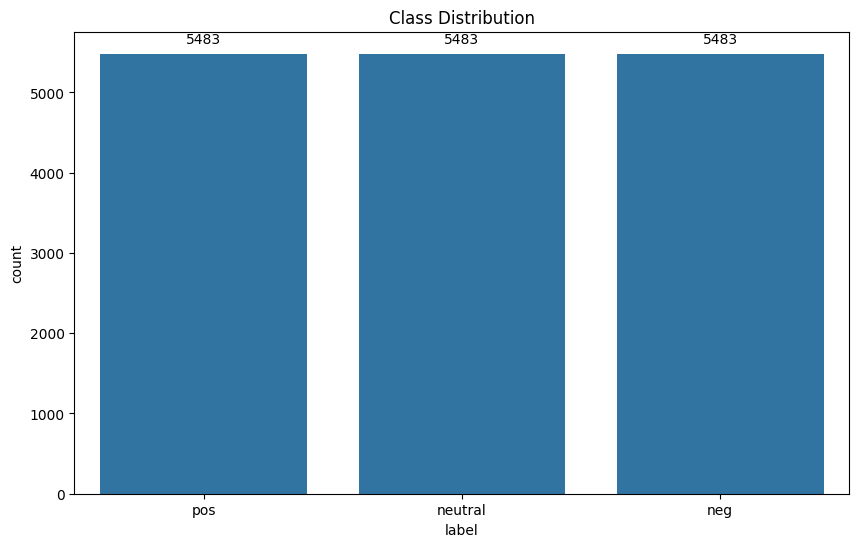

CPU times: user 232 ms, sys: 182 ms, total: 414 ms
Wall time: 160 ms


In [ ]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='label', data=balanced_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.show()

### Text Length Distribution

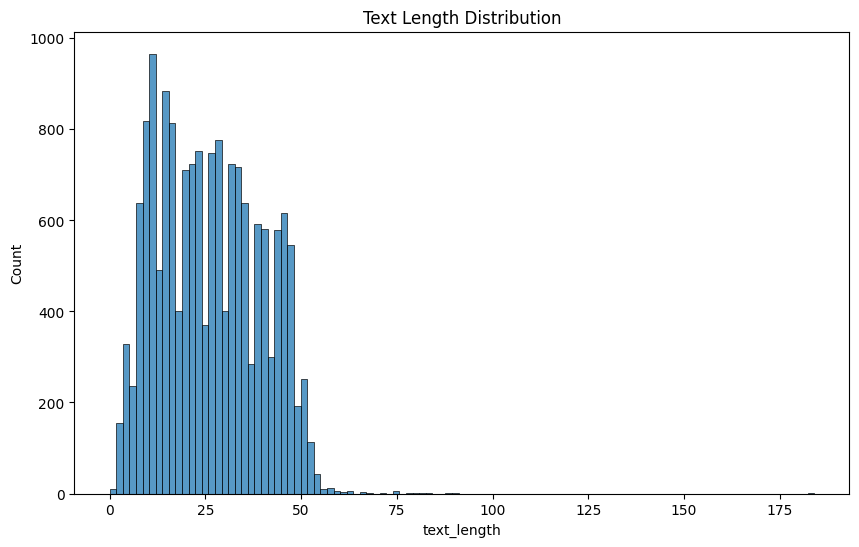

CPU times: user 300 ms, sys: 99.6 ms, total: 400 ms
Wall time: 282 ms


In [ ]:
%%time

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
balanced_df['text_length'] = balanced_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(balanced_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

### Most Frequent Words

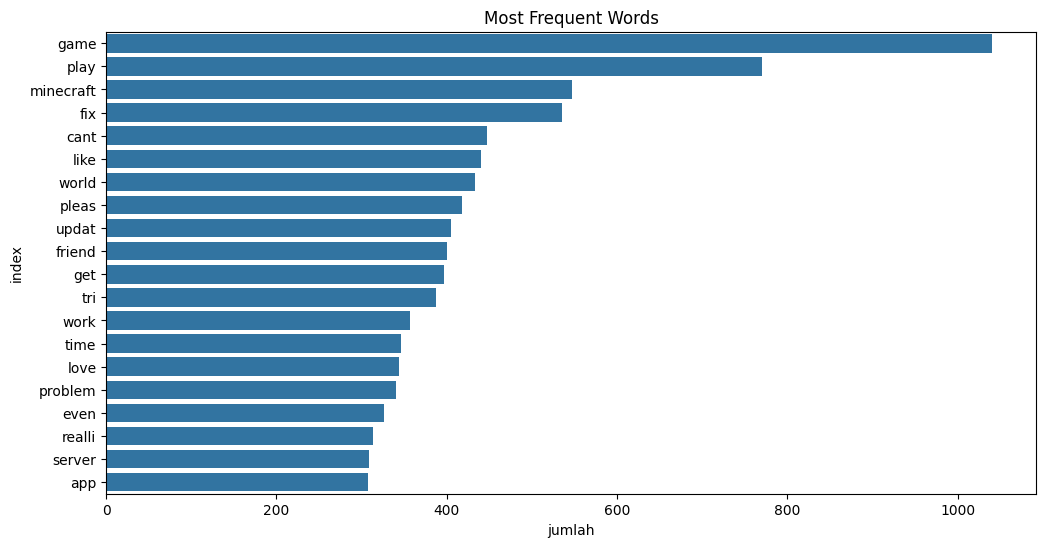

CPU times: user 1.32 s, sys: 974 ms, total: 2.3 s
Wall time: 2.17 s


In [ ]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(balanced_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

### Word Cloud of Positive Review Data

In [23]:
# Membuat DataFrame baru 'positive_reviews' yang hanya berisi review dengan polaritas positif.
positive_reviews = balanced_df[balanced_df['label'] == 'pos']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_reviews'.
positive_reviews = positive_reviews[['text_akhir', 'label','text_stopword']]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_reviews = positive_reviews.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_reviews.index += 1

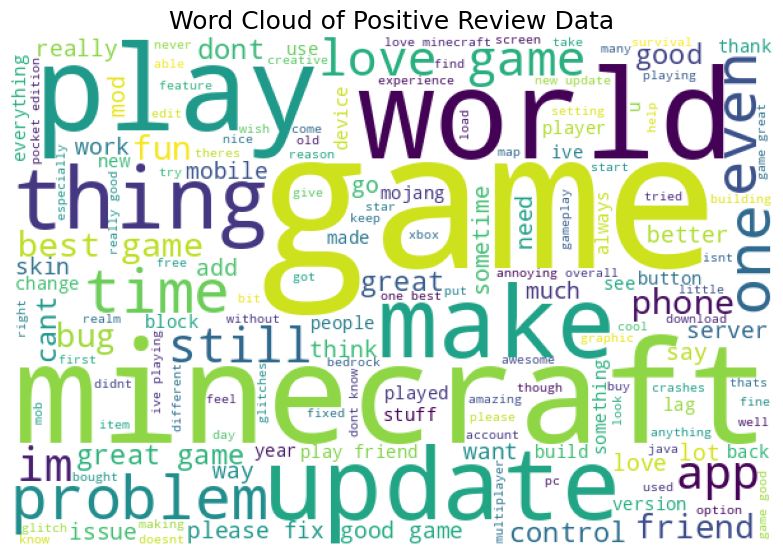

CPU times: user 35.5 s, sys: 4.84 s, total: 40.3 s
Wall time: 40.8 s


In [ ]:
%%time

# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam review positif.
list_words = ''

# Iterasi melalui setiap review dalam kolom 'text_stopword' dari DataFrame 'positive_reviews'.
for review in positive_reviews['text_stopword']:
    # Iterasi melalui setiap kata dalam review.
    for word in review:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Positive Review Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

### Word Cloud of Neutral Review Data

In [25]:
# Membuat DataFrame baru 'neutral_reviews' yang hanya berisi review dengan polaritas positif.
neutral_reviews = balanced_df[balanced_df['label'] == 'neutral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'neutral_reviews'.
neutral_reviews = neutral_reviews[['text_akhir', 'label','text_stopword']]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
neutral_reviews = neutral_reviews.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
neutral_reviews.index += 1

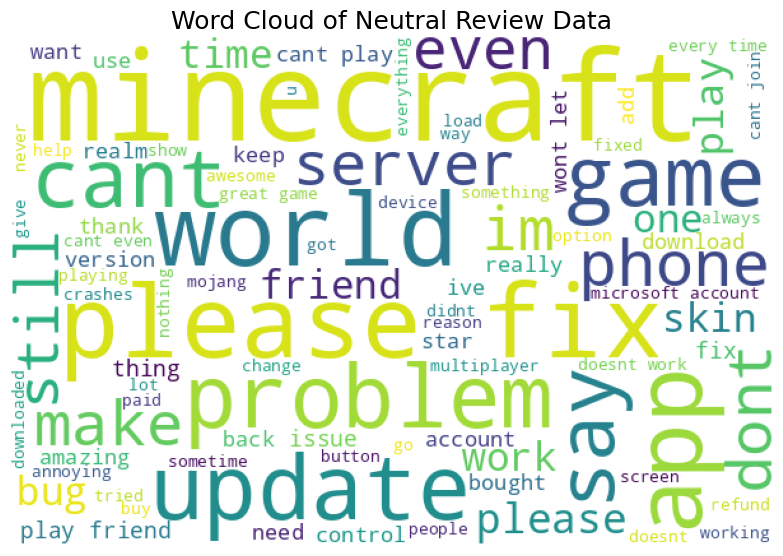

CPU times: user 6.21 s, sys: 200 ms, total: 6.41 s
Wall time: 6.44 s


In [ ]:
%%time

# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam review netral.
list_words = ''

# Iterasi melalui setiap review dalam kolom 'text_stopword' dari DataFrame 'neutral_reviews'.
for review in neutral_reviews['text_stopword']:
    # Iterasi melalui setiap kata dalam review.
    for word in review:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Neutral Review Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

### Word Cloud of Negative Review Data

In [27]:
# Membuat DataFrame baru 'negative_reviews' yang hanya berisi review dengan polaritas negatif.
negative_reviews = balanced_df[balanced_df['label'] == 'neg']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_reviews'.
negative_reviews = negative_reviews[['text_akhir', 'label','text_stopword']]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_reviews = negative_reviews.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_reviews.index += 1

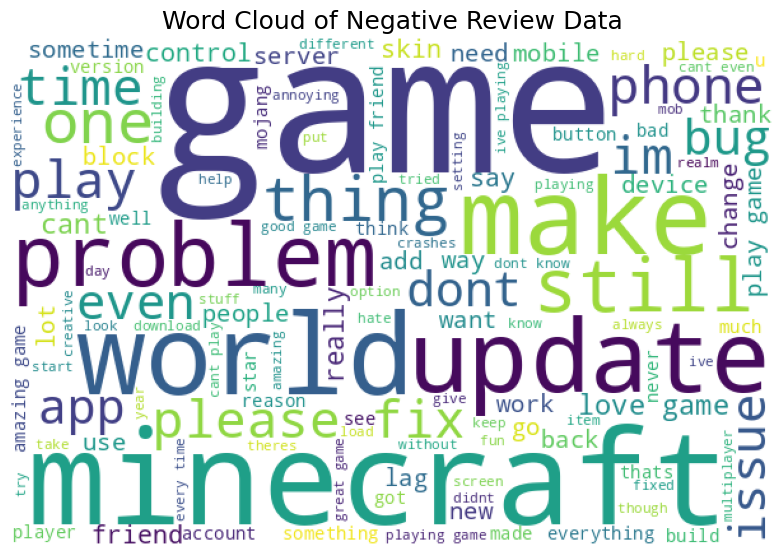

CPU times: user 11.3 s, sys: 233 ms, total: 11.5 s
Wall time: 11.4 s


In [ ]:
%%time

# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam review negatif.
list_words = ''

# Iterasi melalui setiap review dalam kolom 'text_stopword' dari DataFrame 'negative_reviews'.
for review in negative_reviews['text_stopword']:
    # Iterasi melalui setiap kata dalam review.
    for word in review:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Review Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

# **Skema 1: Machine Learning + 9:1 Train-Test Split**

## Feature Extraction (TF-IDF)

In [29]:
balanced_df.head(1)

,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_stemmingText,text_akhir,polarity,label,text_length
0,I really like the game but my account lost all...,I really like the game but my account lost all...,i really like the game but my account lost all...,"[i, really, like, the, game, but, my, account,...","[really, like, game, account, lost, mine, coin...","[realli, like, game, account, lost, mine, coin...",realli like game account lost mine coin editor...,0.23125,pos,54


In [60]:
# Pisahkan data menjadi fitur dan label (sentimen)
X = balanced_df['text_akhir']
y = balanced_df['label']

In [61]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)

In [62]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,aaa,aaaaaa,aaaaaaaaaaaa,aad,aadon,aam,aand,aap,ab,abandon,...,𝚝𝚑𝚎,𝚝𝚑𝚒𝚜,𝚝𝚘,𝚝𝚛𝚢,𝚞𝚙,𝚟𝚎𝚛𝚢,𝚟𝚒𝚘𝚕𝚊𝚗𝚌𝚎,𝚠𝚒𝚕𝚕,𝚠𝚒𝚝𝚑,𝚠𝚘𝚗𝚍𝚎𝚛𝚒𝚗𝚐
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Splitting (9:1)

In [63]:
# Bagi data menjadi data latih dan data uji (90% data latih, 10% data uji)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.1, random_state=42)

# Menampilkan dimensi data latih dan data uji
print("Dimensi data latih:", X_train.shape, y_train.shape)
print("Dimensi data uji:", X_test.shape, y_test.shape)

Dimensi data latih: (14804, 12734) (14804,)
Dimensi data uji: (1645, 12734) (1645,)


## Model Training

### Logistic Regression

In [ ]:
%%time

# Membuat objek model Logistic Regression
lr_model = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
lr_model.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = lr_model.predict(X_train.toarray())
y_pred_test_lr = lr_model.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.9377870845717373
Logistic Regression - accuracy_test: 0.8723404255319149
CPU times: user 1min 40s, sys: 23.2 s, total: 2min 3s
Wall time: 42.7 s


### Naive Bayes

In [ ]:
%%time

# Membuat objek model Naive Bayes
nb_model = MultinomialNB()

# Melatih model Naive Bayes pada data pelatihan
nb_model.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = nb_model.predict(X_train.toarray())
y_pred_test_nb = nb_model.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes pada data pelatihan
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)

# Evaluasi akurasi model Naive Bayes pada data uji
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.747433126182113
Naive Bayes - accuracy_test: 0.6443768996960486
CPU times: user 2.17 s, sys: 2 s, total: 4.17 s
Wall time: 2.79 s


### K-Nearest Neighbors

In [ ]:
%%time

# Membuat objek model K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Melatih model K-Nearest Neighbors pada data pelatihan
knn_model.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_knn = knn_model.predict(X_train.toarray())
y_pred_test_knn = knn_model.predict(X_test.toarray())

# Evaluasi akurasi model K-Nearest Neighbors pada data pelatihan
accuracy_train_knn = accuracy_score(y_pred_train_knn, y_train)

# Evaluasi akurasi model K-Nearest Neighbors pada data uji
accuracy_test_knn = accuracy_score(y_pred_test_knn, y_test)

# Menampilkan akurasi
print('K-Nearest Neighbors - accuracy_train:', accuracy_train_knn)
print('K-Nearest Neighbors - accuracy_test:', accuracy_test_knn)

K-Nearest Neighbors - accuracy_train: 0.5924074574439341
K-Nearest Neighbors - accuracy_test: 0.4723404255319149
CPU times: user 3min 8s, sys: 2.48 s, total: 3min 10s
Wall time: 1min 2s


### Decision Tree

In [ ]:
%%time

# Membuat objek model Decision Tree
dt_model = DecisionTreeClassifier()

# Melatih model Decision Tree pada data pelatihan
dt_model.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = dt_model.predict(X_train.toarray())
y_pred_test_dt = dt_model.predict(X_test.toarray())

# Evaluasi akurasi model Decision Tree pada data pelatihan
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)

# Evaluasi akurasi model Decision Tree pada data uji
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 1.0
Decision Tree - accuracy_test: 0.8231003039513678
CPU times: user 39.9 s, sys: 1.66 s, total: 41.6 s
Wall time: 41.6 s


### Random Forest

In [ ]:
%%time

# Membuat objek model Random Forest
rf_model = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
rf_model.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = rf_model.predict(X_train.toarray())
y_pred_test_rf = rf_model.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest pada data pelatihan
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)

# Evaluasi akurasi model Random Forest pada data uji
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 1.0
Random Forest - accuracy_test: 0.8018237082066869
CPU times: user 52.6 s, sys: 1.66 s, total: 54.2 s
Wall time: 54.3 s


## Review Prediction

In [57]:
def review_predict(text):
    # Melakukan preprocessing pada kalimat baru
    kalimat_baru_cleaned = cleaningText(text)
    kalimat_baru_casefolded = casefoldingText(kalimat_baru_cleaned)
    kalimat_baru_tokenized = tokenizingText(kalimat_baru_casefolded)
    kalimat_baru_filtered = filteringText(kalimat_baru_tokenized)
    kalimat_baru_stemmed = stemmingText(kalimat_baru_filtered)
    kalimat_baru_final = toSentence(kalimat_baru_stemmed)

    # Menggunakan objek tfidf yang sudah di-fit dari pelatihan sebelumnya
    X_kalimat_baru = tfidf.transform([kalimat_baru_final])

    # Memperoleh prediksi sentimen kalimat baru
    models = {
      "Logistic Regression": lr_model,
      "Naive Bayes": nb_model,
      "K-Nearest Neighbors": knn_model,
      "Decision Tree": dt_model,
      "Random Forest": rf_model
    }

    for model_name, model in models.items():
      prediction = model.predict(X_kalimat_baru)
      if prediction == "pos":
        print(f"{model_name}: Kalimat positif")
      elif prediction == "neg":
        print(f"{model_name}: Kalimat negatif")
      else:
        print(f"{model_name}: Kalimat neutral")

In [ ]:
# Mendapatkan review acak dari dataframe
random_review = balanced_df.sample(n=1)['content'].values[0]
print("Random Review:", random_review)

review_predict(random_review)

Random Review: Amazing! I love Minecraft so much but I have to delete a lot of my apps to update it :< Edit:Can't even update it I had to delete so much and it wont even update. Edit 2: can't even play on my account
Logistic Regression: Kalimat positif
Naive Bayes: Kalimat positif
K-Nearest Neighbors: Kalimat neutral
Decision Tree: Kalimat positif
Random Forest: Kalimat neutral


# **Skema 2: LSTM + 8:2 Train-Test Split**

In [69]:
MAX_NB_WORDS = 50000 # Jumlah kata yang akan digunakan
MAX_SEQUENCE_LENGTH = 250 # Panjang maksimum dari setiap kalimat
EMBEDDING_DIM = 100 # Dimensi vektor embedding

## Tokenization

In [70]:
tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(balanced_df['text_akhir'])
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 12778 unique tokens.


In [102]:
# Save the tokenizer to a file
with open('Model/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [71]:
X = tokenizer.texts_to_sequences(balanced_df['text_akhir'])
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (16449, 250)


In [72]:
Y = pd.get_dummies(balanced_df['label']).values
print('Shape of label tensor:', Y.shape)

Shape of label tensor: (16449, 3)


## Data Splitting (8:2)

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(13159, 250) (13159, 3)
(3290, 250) (3290, 3)


## Model Training

### LSTM

In [74]:
# Define the LSTM model architecture
lstm_model = Sequential()
lstm_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/home/bima/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Membuat callback untuk menghentikan training model apabila val_accuracy lebih atau sama dengan 92%
class StopAtValAccuracy(Callback):
    def __init__(self, threshold=0.92):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        if val_acc is not None and val_acc >= self.threshold:
            print(f"\n✅ Reached {val_acc:.4f} validation accuracy. Stopping training.")
            self.model.stop_training = True

# Then use it in training:
stop_callback = StopAtValAccuracy(threshold=0.92)

In [76]:
%%time

# Train the LSTM model
epochs = 20
batch_size = 64
history_lstm = lstm_model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[stop_callback]
)

Epoch 1/20


186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 194ms/step - accuracy: 0.5481 - loss: 0.8775 - val_accuracy: 0.7895 - val_loss: 0.5237
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 39s 210ms/step - accuracy: 0.8233 - loss: 0.4409 - val_accuracy: 0.8647 - val_loss: 0.3455
Epoch 3/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 228ms/step - accuracy: 0.9086 - loss: 0.2530 - val_accuracy: 0.8647 - val_loss: 0.3465
Epoch 4/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 44s 236ms/step - accuracy: 0.9408 - loss: 0.1729 - val_accuracy: 0.8974 - val_loss: 0.2703
Epoch 5/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 43s 233ms/step - accuracy: 0.9557 - loss: 0.1341 - val_accuracy: 0.9081 - val_loss: 0.2647
Epoch 6/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 43s 231ms/step - accuracy: 0.9690 - loss: 0.0953 - val_accuracy: 0.8982 - val_loss: 0.2982
Epoch 7/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9714 - loss: 0.0840 - val_accuracy: 0.9119 - val_loss: 0.2766
Epoch 8/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 83s 227ms/step - accuracy: 0.9756 - loss: 0.0725 - val

In [77]:
accuracy_train_lstm = lstm_model.evaluate(X_train, Y_train)
print('LSTM - accuracy_train:', accuracy_train_lstm[1])

412/412 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9958 - loss: 0.0121
LSTM - accuracy_train: 0.9880689978599548


In [78]:
accuracy_test_lstm = lstm_model.evaluate(X_test, Y_test)
print('LSTM - accuracy_test:', accuracy_test_lstm[1])

103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9061 - loss: 0.4103
LSTM - accuracy_test: 0.9103343486785889


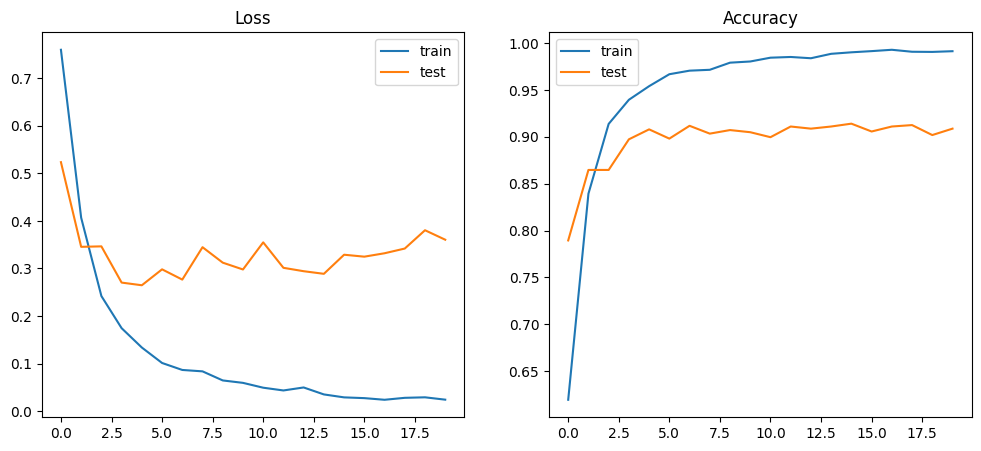

In [80]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss on the first subplot
ax1.set_title('Loss')
ax1.plot(history_lstm.history['loss'], label='train')
ax1.plot(history_lstm.history['val_loss'], label='test')
ax1.legend()

# Plot Accuracy on the second subplot
ax2.set_title('Accuracy')
ax2.plot(history_lstm.history['accuracy'], label='train')
ax2.plot(history_lstm.history['val_accuracy'], label='test')
ax2.legend()

# Display the plots
plt.show()

### Bi-LSTM

In [82]:
# Define the Bi-LSTM model architecture
bilstm_model = Sequential()
bilstm_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
bilstm_model.add(SpatialDropout1D(0.2))
bilstm_model.add(Bidirectional(LSTM(100, dropout=0.2, recurrent_dropout=0.2)))
bilstm_model.add(Dense(3, activation='softmax'))
bilstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/home/bima/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [83]:
%%time

# Train the Bi-LSTM model
epochs = 20
batch_size = 64
history_bilstm = bilstm_model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[stop_callback]
)

Epoch 1/20


186/186 ━━━━━━━━━━━━━━━━━━━━ 88s 437ms/step - accuracy: 0.5251 - loss: 0.8949 - val_accuracy: 0.7956 - val_loss: 0.4923
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 97s 524ms/step - accuracy: 0.8275 - loss: 0.4444 - val_accuracy: 0.8663 - val_loss: 0.3422
Epoch 3/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 81s 435ms/step - accuracy: 0.9120 - loss: 0.2411 - val_accuracy: 0.8837 - val_loss: 0.2868
Epoch 4/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 81s 435ms/step - accuracy: 0.9422 - loss: 0.1651 - val_accuracy: 0.9050 - val_loss: 0.2601
Epoch 5/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 84s 452ms/step - accuracy: 0.9532 - loss: 0.1368 - val_accuracy: 0.9103 - val_loss: 0.2784
Epoch 6/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 85s 459ms/step - accuracy: 0.9643 - loss: 0.1067 - val_accuracy: 0.9065 - val_loss: 0.2964
Epoch 7/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 83s 444ms/step - accuracy: 0.9722 - loss: 0.0832 - val_accuracy: 0.9027 - val_loss: 0.2999
Epoch 8/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 84s 446ms/step - accuracy: 0.9747 - loss: 0.0800 - val

In [84]:
accuracy_train_bilstm = bilstm_model.evaluate(X_train, Y_train)
print('Bi-LSTM - accuracy_train:', accuracy_train_bilstm[1])

412/412 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9935 - loss: 0.0235
Bi-LSTM - accuracy_train: 0.9866251349449158


In [85]:
accuracy_test_bilstm = bilstm_model.evaluate(X_test, Y_test)
print('Bi-LSTM - accuracy_test:', accuracy_test_bilstm[1])

103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9065 - loss: 0.3205
Bi-LSTM - accuracy_test: 0.9133738875389099


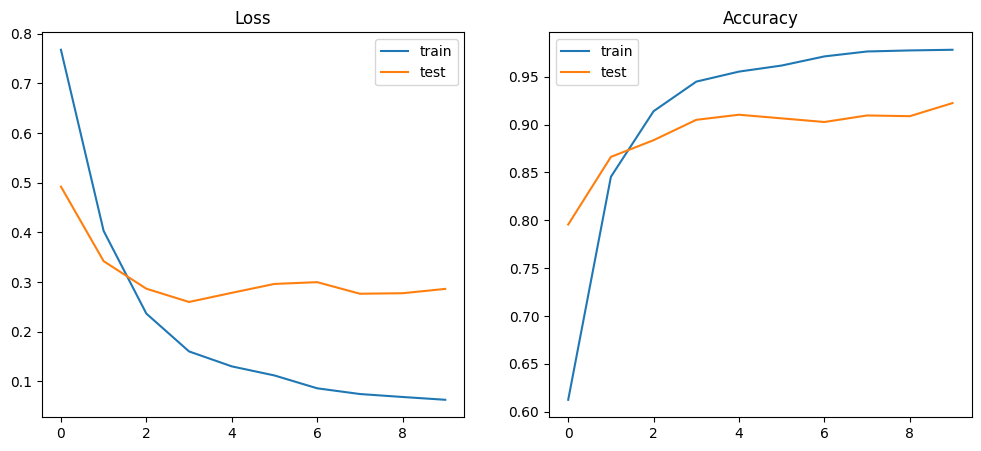

In [86]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss on the first subplot
ax1.set_title('Loss')
ax1.plot(history_bilstm.history['loss'], label='train')
ax1.plot(history_bilstm.history['val_loss'], label='test')
ax1.legend()

# Plot Accuracy on the second subplot
ax2.set_title('Accuracy')
ax2.plot(history_bilstm.history['accuracy'], label='train')
ax2.plot(history_bilstm.history['val_accuracy'], label='test')
ax2.legend()

# Display the plots
plt.show()

In [100]:
bilstm_model.save('Model/bilstm_model.keras')

## Review Prediction

### LSTM

In [48]:
random_review = balanced_df.sample(n=1)['content'].values[0]
print("Random Review:", random_review)

seq = tokenizer.texts_to_sequences([random_review])
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = lstm_model.predict(padded)
labels = ['neg', 'neutral', 'pos']
print(pred, labels[np.argmax(pred)])

Random Review: The game has come very far in the past 9 years. I love everything about it now, it's like my perfect sandbox game in creative, and a personalized world building game in survival. The only problem I'm having is, even when I have cellular data turned on the app, I'm still not able to play online or with friends. Is there any reason for this, and could I get some help? Thanks so much, otherwise the game is GREAT and I'm playing a LOT more often now!!!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
[[1.0005749e-05 5.0464823e-06 9.9998498e-01]] pos


### Bi-LSTM

In [ ]:
random_review = balanced_df.sample(n=1)['content'].values[0]
print("Random Review:", random_review)

seq = tokenizer.texts_to_sequences([random_review])
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = bilstm_model.predict(padded)
labels = ['neg', 'neutral', 'pos']
print(pred, labels[np.argmax(pred)])

Random Review: A really good game, but if you don't have a control pad attached, I'd think twice, because the mobile phone controls are infuriatingly difficult to use.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
[[9.9851781e-01 1.0501621e-03 4.3214421e-04]] neg


# **Skema 3: CNN + 7:3 Train-Test Split**

## Data Splitting (7:3)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

## Model Training

In [ ]:
# Define the CNN model architecture
cnn_model = Sequential()
cnn_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
cnn_model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(3, activation='softmax'))
cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

CPU times: user 8.38 ms, sys: 975 μs, total: 9.35 ms
Wall time: 10.7 ms


/home/bima/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
%%time

# Train the CNN model
epochs = 20
batch_size = 64
history_cnn = cnn_model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[stop_callback]
)

Epoch 1/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.6027 - loss: 0.8192 - val_accuracy: 0.8663 - val_loss: 0.3526
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9120 - loss: 0.2561 - val_accuracy: 0.9111 - val_loss: 0.2667
Epoch 3/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9600 - loss: 0.1250 - val_accuracy: 0.9058 - val_loss: 0.2994
Epoch 4/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9777 - loss: 0.0788 - val_accuracy: 0.9126 - val_loss: 0.3168
Epoch 5/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9884 - loss: 0.0410 - val_accuracy: 0.9119 - val_loss: 0.3366
Epoch 6/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9926 - loss: 0.0284 - val_accuracy: 0.9103 - val_loss: 0.3898
Epoch 7/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9946 - loss: 0.0207 - val_accuracy: 0.9157 - val_loss: 0.3959
Epoch 8/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9980 - loss: 0.0110 - 

In [53]:
# Evaluate the CNN model on training data
accuracy_train_cnn = cnn_model.evaluate(X_train, Y_train)
print('CNN - accuracy_train:', accuracy_train_cnn[1])

412/412 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9995 - loss: 0.0036 
CNN - accuracy_train: 0.9914126992225647


In [54]:
# Evaluate the CNN model on test data
accuracy_test_cnn = cnn_model.evaluate(X_test, Y_test)
print('CNN - accuracy_test:', accuracy_test_cnn[1])

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8954 - loss: 0.6834
CNN - accuracy_test: 0.9006078839302063


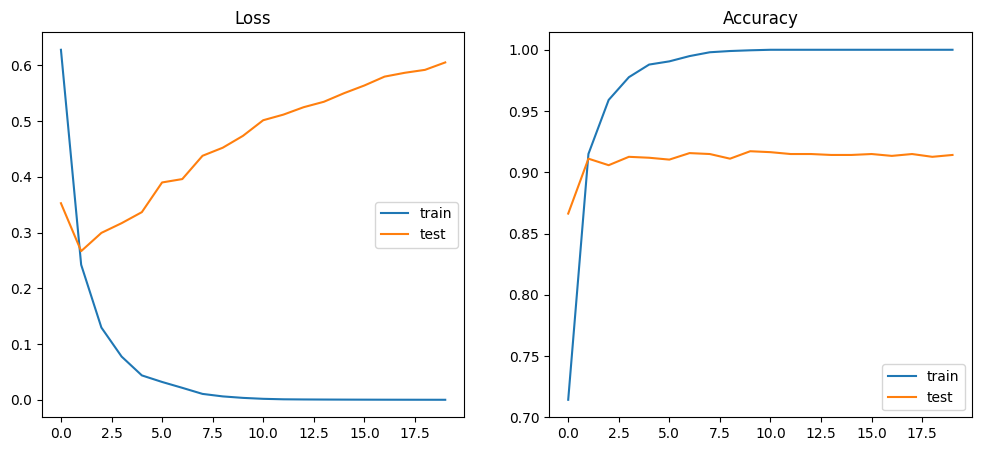

In [56]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss on the first subplot
ax1.set_title('Loss')
ax1.plot(history_cnn.history['loss'], label='train')
ax1.plot(history_cnn.history['val_loss'], label='test')
ax1.legend()

# Plot Accuracy on the second subplot
ax2.set_title('Accuracy')
ax2.plot(history_cnn.history['accuracy'], label='train')
ax2.plot(history_cnn.history['val_accuracy'], label='test')
ax2.legend()

# Display the plots
plt.show()

# **Accuracy Comparison**

In [91]:
# Membuat DataFrame untuk hasil akurasi
accuracy_df = pd.DataFrame({
    'Model': [
        'Skema 1 (Logistic Regression + 90-10)', 
        'Skema 1 (Naive Bayes + 90-10)', 
        'Skema 1 (K-Nearest Neighbors + 90-10)', 
        'Skema 1 (Decision Tree + 90-10)', 
        'Skema 1 (Random Forest + 90-10)', 
        'Skema 2 (LSTM + 80-20)', 
        'Skema 2 (Bi-LSTM + 80-20)', 
        'Skema 3 (CNN + 70-30)'
    ],
    'Accuracy Train': [
        accuracy_train_lr, 
        accuracy_train_nb, 
        accuracy_train_knn, 
        accuracy_train_dt, 
        accuracy_train_rf, 
        accuracy_train_lstm[1], 
        accuracy_train_bilstm[1], 
        accuracy_train_cnn[1]
    ],
    'Accuracy Test': [
        accuracy_test_lr, 
        accuracy_test_nb, 
        accuracy_test_knn, 
        accuracy_test_dt, 
        accuracy_test_rf, 
        accuracy_test_lstm[1], 
        accuracy_test_bilstm[1], 
        accuracy_test_cnn[1]
    ]
})
# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_df = accuracy_df.sort_values(by='Accuracy Test', ascending=False)
# Mengatur ulang indeks DataFrame agar dimulai dari 0.
accuracy_df = accuracy_df.reset_index(drop=True)
accuracy_df

,Model,Accuracy Train,Accuracy Test
0,Skema 2 (Bi-LSTM + 80-20),0.986625,0.913374
1,Skema 2 (LSTM + 80-20),0.988069,0.910334
2,Skema 3 (CNN + 70-30),0.991413,0.900608
3,Skema 1 (Logistic Regression + 90-10),0.937787,0.872340
4,Skema 1 (Decision Tree + 90-10),1.000000,0.823100
5,Skema 1 (Random Forest + 90-10),1.000000,0.801824
6,Skema 1 (Naive Bayes + 90-10),0.747433,0.644377
7,Skema 1 (K-Nearest Neighbors + 90-10),0.592407,0.472340


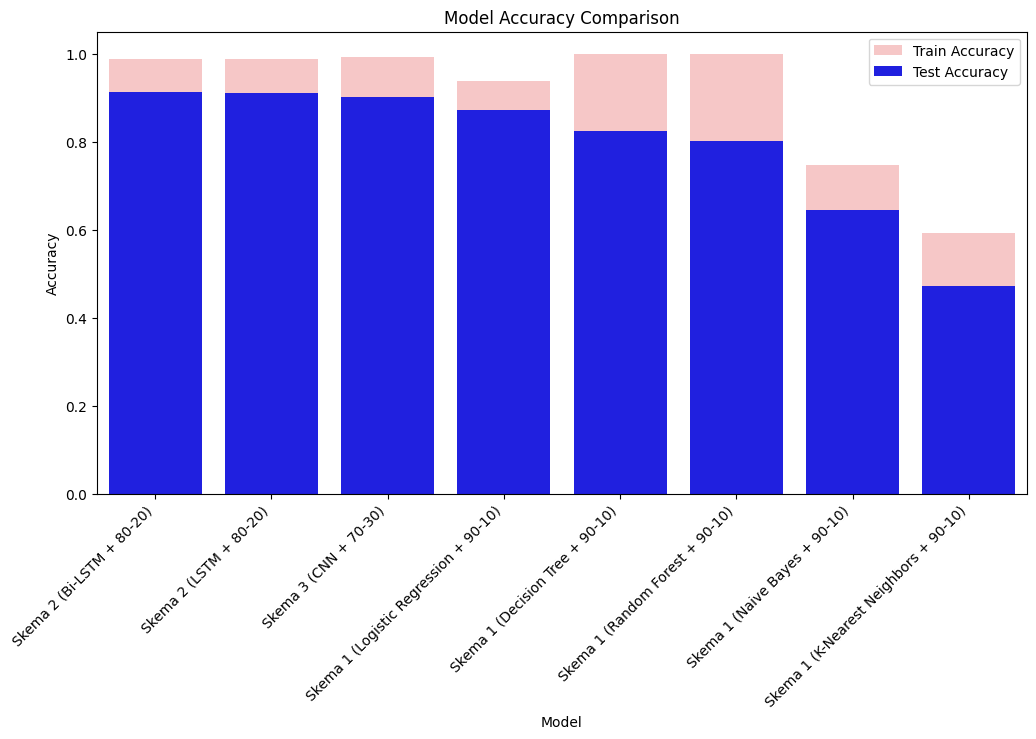

In [99]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Create a bar plot for Accuracy Train and Accuracy Test
sns.barplot(x='Model', y='Accuracy Train', data=accuracy_df, color='red', alpha=0.25, label='Train Accuracy')
sns.barplot(x='Model', y='Accuracy Test', data=accuracy_df, color='blue', label='Test Accuracy')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add title and labels
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

# Add legend
plt.legend()

# Display the plot
plt.show()

Berdasarkan hasil evaluasi model, berikut adalah tiga model dengan akurasi test terbesar:

1. **Bi-LSTM (Skema 2: LSTM + 8:2 Train-Test Split)**
    - **Akurasi Train:** 98.66%
    - **Akurasi Test:** 91.34%
    - **Penjelasan:** Bi-LSTM (Bidirectional Long Short-Term Memory) adalah varian dari LSTM yang memproses input dalam dua arah, yaitu maju dan mundur. Hal ini memungkinkan model untuk menangkap informasi dari konteks sebelumnya dan berikutnya dalam data teks, sehingga meningkatkan kemampuan model dalam memahami dan memprediksi sentimen dari ulasan.

2. **LSTM (Skema 2: LSTM + 8:2 Train-Test Split)**
    - **Akurasi Train:** 98.81%
    - **Akurasi Test:** 91.03%
    - **Penjelasan:** LSTM (Long Short-Term Memory) adalah jenis jaringan saraf berulang (RNN) yang dirancang untuk mengatasi masalah vanishing gradient pada RNN tradisional. LSTM memiliki kemampuan untuk mengingat informasi dalam jangka waktu yang lebih lama, sehingga sangat efektif dalam memproses data teks yang memiliki dependensi jangka panjang.

3. **CNN (Skema 3: CNN + 7:3 Train-Test Split)**
    - **Akurasi Train:** 99.14%
    - **Akurasi Test:** 90.06%
    - **Penjelasan:** CNN (Convolutional Neural Network) adalah jenis jaringan saraf yang biasanya digunakan untuk pengenalan gambar, tetapi juga dapat diterapkan pada data teks. CNN menggunakan lapisan konvolusi untuk mengekstraksi fitur penting dari teks, yang kemudian digunakan untuk klasifikasi sentimen. CNN sangat efektif dalam menangkap pola lokal dalam data teks.

Ketiga model ini menggunakan algoritma deep learning yang mampu menangkap pola kompleks dalam data teks, sehingga menghasilkan akurasi yang tinggi dalam prediksi sentimen ulasan.